
Training with lambda = 0.1
Epoch 1, Loss: 1452.61
Epoch 2, Loss: 1237.62
Epoch 3, Loss: 1155.44
Epoch 4, Loss: 1092.77
Epoch 5, Loss: 1037.40
Epoch 6, Loss: 990.31
Epoch 7, Loss: 948.51
Epoch 8, Loss: 909.63
Epoch 9, Loss: 871.86
Epoch 10, Loss: 839.64
Epoch 11, Loss: 805.85
Epoch 12, Loss: 771.02
Epoch 13, Loss: 740.09
Epoch 14, Loss: 709.65
Epoch 15, Loss: 678.30
Epoch 16, Loss: 650.17
Epoch 17, Loss: 618.12
Epoch 18, Loss: 593.16
Epoch 19, Loss: 562.41
Epoch 20, Loss: 535.27
Lambda: 0.1, Accuracy: 53.24%, Sparsity: 68.49%


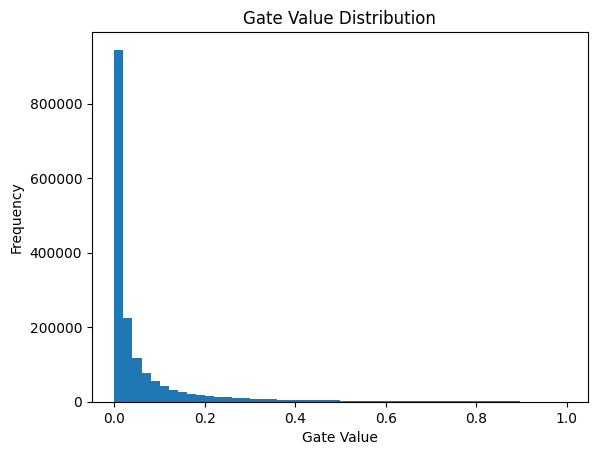


Training with lambda = 0.2
Epoch 1, Loss: 1465.99
Epoch 2, Loss: 1247.12
Epoch 3, Loss: 1164.87
Epoch 4, Loss: 1104.69
Epoch 5, Loss: 1050.93
Epoch 6, Loss: 1003.63
Epoch 7, Loss: 960.92
Epoch 8, Loss: 923.64
Epoch 9, Loss: 889.88
Epoch 10, Loss: 853.89
Epoch 11, Loss: 823.27
Epoch 12, Loss: 789.77
Epoch 13, Loss: 758.33
Epoch 14, Loss: 728.93
Epoch 15, Loss: 697.91
Epoch 16, Loss: 670.10
Epoch 17, Loss: 640.40
Epoch 18, Loss: 611.73
Epoch 19, Loss: 582.81
Epoch 20, Loss: 556.69
Lambda: 0.2, Accuracy: 54.38%, Sparsity: 69.89%


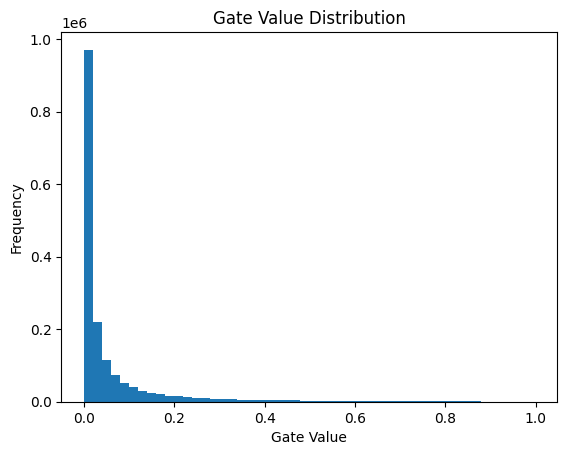


Training with lambda = 0.3
Epoch 1, Loss: 1474.11
Epoch 2, Loss: 1257.90
Epoch 3, Loss: 1174.07
Epoch 4, Loss: 1115.04
Epoch 5, Loss: 1065.42
Epoch 6, Loss: 1017.75
Epoch 7, Loss: 978.03
Epoch 8, Loss: 940.46
Epoch 9, Loss: 904.18
Epoch 10, Loss: 870.97
Epoch 11, Loss: 839.27
Epoch 12, Loss: 806.93
Epoch 13, Loss: 775.65
Epoch 14, Loss: 747.39
Epoch 15, Loss: 717.35
Epoch 16, Loss: 687.24
Epoch 17, Loss: 660.58
Epoch 18, Loss: 631.71
Epoch 19, Loss: 604.47
Epoch 20, Loss: 578.16
Lambda: 0.3, Accuracy: 54.24%, Sparsity: 71.25%


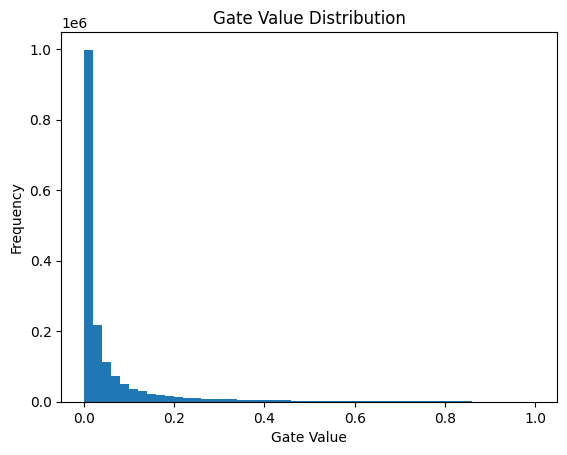


Final Results:
Lambda: 0.1, Accuracy: 53.24%, Sparsity: 68.49%
Lambda: 0.2, Accuracy: 54.38%, Sparsity: 69.89%
Lambda: 0.3, Accuracy: 54.24%, Sparsity: 71.25%


In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ----------------------------
# 1. Prunable Linear Layer
# ----------------------------
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # 🔥 Negative init (IMPORTANT)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) - 2.0)

    def forward(self, x):
        temperature = 0.5
        gates = torch.sigmoid(self.gate_scores / temperature)

        pruned_weights = self.weight * gates
        return torch.matmul(x, pruned_weights.t()) + self.bias

    def get_gates(self):
        temperature = 0.5
        return torch.sigmoid(self.gate_scores / temperature)


# ----------------------------
# 2. Model
# ----------------------------
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.relu1 = nn.ReLU()

        self.fc2 = PrunableLinear(512, 256)
        self.relu2 = nn.ReLU()

        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_all_gates(self):
        gates = []
        for layer in self.modules():
            if isinstance(layer, PrunableLinear):
                gates.append(layer.get_gates())
        return gates


# ----------------------------
# 3. Sparsity Loss
# ----------------------------
def sparsity_loss(model):
    loss = 0
    for gates in model.get_all_gates():
        loss += torch.mean(gates)
    return loss


# ----------------------------
# 4. Data
# ----------------------------
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=64, shuffle=False)


# ----------------------------
# 5. Training
# ----------------------------
def train_model(lambda_val):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = PrunableNet().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    epochs = 20   # more epochs for better pruning

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            class_loss = criterion(outputs, labels)
            sparse_loss = sparsity_loss(model)

            loss = class_loss + lambda_val * sparse_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

    return model


# ----------------------------
# 6. Evaluation
# ----------------------------
def evaluate(model, threshold=0.04):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    total_weights, zero_weights = 0, 0

    for gates in model.get_all_gates():
        total_weights += gates.numel()
        zero_weights += torch.sum(gates < threshold).item()

    sparsity = 100 * zero_weights / total_weights

    return accuracy, sparsity


# ----------------------------
# 7. Hard Pruning (Optional)
# ----------------------------
def hard_prune(model, threshold=0.04):
    for layer in model.modules():
        if isinstance(layer, PrunableLinear):
            gates = layer.get_gates()
            mask = (gates > threshold).float()
            layer.weight.data *= mask


# ----------------------------
# 8. Plot Gates
# ----------------------------
def plot_gates(model):
    all_gates = []

    for gates in model.get_all_gates():
        all_gates.extend(gates.detach().cpu().numpy().flatten())

    plt.hist(all_gates, bins=50)
    plt.title("Gate Value Distribution")
    plt.xlabel("Gate Value")
    plt.ylabel("Frequency")
    plt.show()


# ----------------------------
# 9. Run Experiments
# ----------------------------
lambdas = [0.1, 0.2, 0.3]
results = []

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")

    model = train_model(lam)

    acc, sparsity = evaluate(model)

    results.append((lam, acc, sparsity))

    print(f"Lambda: {lam}, Accuracy: {acc:.2f}%, Sparsity: {sparsity:.2f}%")

    plot_gates(model)


# ----------------------------
# 10. Final Results
# ----------------------------
print("\nFinal Results:")
for r in results:
    print(f"Lambda: {r[0]}, Accuracy: {r[1]:.2f}%, Sparsity: {r[2]:.2f}%")

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [13]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Negative init for pruning
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features) - 2.0)

    def forward(self, x):
        temperature = 0.5
        gates = torch.sigmoid(self.gate_scores / temperature)
        pruned_weights = self.weight * gates
        return torch.matmul(x, pruned_weights.t()) + self.bias

    def get_gates(self):
        temperature = 0.5
        return torch.sigmoid(self.gate_scores / temperature)

In [14]:
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = PrunableLinear(32*32*3, 512)
        self.relu1 = nn.ReLU()

        self.fc2 = PrunableLinear(512, 256)
        self.relu2 = nn.ReLU()

        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_all_gates(self):
        gates = []
        for layer in self.modules():
            if isinstance(layer, PrunableLinear):
                gates.append(layer.get_gates())
        return gates

In [15]:
def sparsity_loss(model):
    loss = 0
    for gates in model.get_all_gates():
        loss += torch.mean(gates)
    return loss

In [16]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

In [17]:
def train_model(lambda_val):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = PrunableNet().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    epochs = 20

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            class_loss = criterion(outputs, labels)
            sparse_loss = sparsity_loss(model)

            loss = class_loss + lambda_val * sparse_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

    return model

In [18]:
def evaluate(model, threshold=0.04):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    correct, total = 0, 0
    total_weights, zero_weights = 0, 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        for gates in model.get_all_gates():
            total_weights += gates.numel()
            zero_weights += torch.sum(gates < threshold).item()

    accuracy = 100 * correct / total
    sparsity = 100 * zero_weights / total_weights

    return accuracy, sparsity

In [19]:
def plot_all_lambdas(models, lambdas):
    plt.figure(figsize=(15, 5))

    for i, (model, lam) in enumerate(zip(models, lambdas)):
        all_gates = []

        for gates in model.get_all_gates():
            all_gates.extend(gates.detach().cpu().numpy().flatten())

        plt.subplot(1, 3, i+1)
        plt.hist(all_gates, bins=50)

        plt.title("Gate Distribution")
        plt.xlabel("Gate Value")
        plt.ylabel("Frequency")

        # λ label below plot
        plt.text(0.5, -0.25, f"λ = {lam}",
                 transform=plt.gca().transAxes,
                 ha='center', fontsize=12)

    plt.tight_layout()
    plt.savefig("combined_gate_distribution.png")
    plt.show()

In [20]:
lambdas = [0.1, 0.2, 0.3]
results = []
models = []

for lam in lambdas:
    print(f"\nTraining with lambda = {lam}")

    model = train_model(lam)

    acc, sparsity = evaluate(model)

    results.append((lam, acc, sparsity))
    models.append(model)

    print(f"Lambda: {lam}, Accuracy: {acc:.2f}%, Sparsity: {sparsity:.2f}%")


Training with lambda = 0.1
Epoch 1, Loss: 1450.88
Epoch 2, Loss: 1236.12
Epoch 3, Loss: 1152.37
Epoch 4, Loss: 1090.83
Epoch 5, Loss: 1036.90
Epoch 6, Loss: 989.15
Epoch 7, Loss: 945.66
Epoch 8, Loss: 906.88
Epoch 9, Loss: 870.53
Epoch 10, Loss: 834.63
Epoch 11, Loss: 801.18
Epoch 12, Loss: 767.28
Epoch 13, Loss: 736.18
Epoch 14, Loss: 702.40
Epoch 15, Loss: 673.64
Epoch 16, Loss: 641.10
Epoch 17, Loss: 611.50
Epoch 18, Loss: 582.44
Epoch 19, Loss: 552.29
Epoch 20, Loss: 525.32
Lambda: 0.1, Accuracy: 53.60%, Sparsity: 68.46%

Training with lambda = 0.2
Epoch 1, Loss: 1469.33
Epoch 2, Loss: 1249.34
Epoch 8, Loss: 929.75
Epoch 9, Loss: 894.32
Epoch 10, Loss: 859.88
Epoch 11, Loss: 827.92
Epoch 12, Loss: 798.38
Epoch 13, Loss: 766.58
Epoch 14, Loss: 733.71
Epoch 15, Loss: 704.37
Epoch 16, Loss: 674.34
Epoch 17, Loss: 645.63
Epoch 18, Loss: 617.72
Epoch 19, Loss: 591.05
Epoch 20, Loss: 562.71
Lambda: 0.2, Accuracy: 53.51%, Sparsity: 69.85%

Training with lambda = 0.3
Epoch 1, Loss: 1485.7

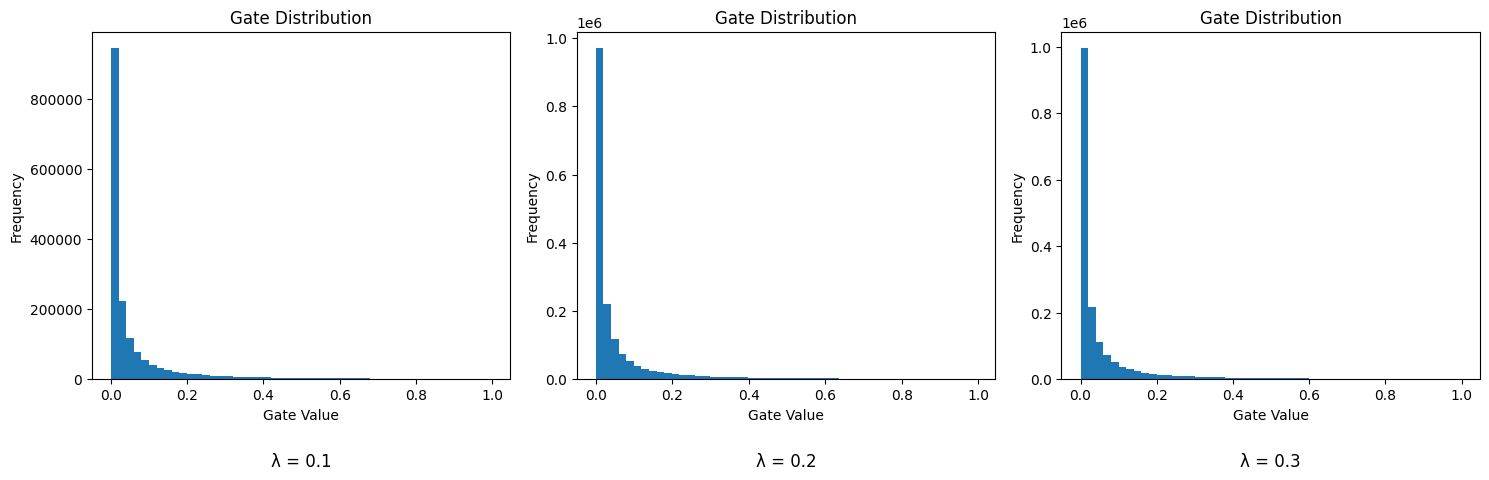


Final Results:
Lambda: 0.1, Accuracy: 53.60%, Sparsity: 68.46%
Lambda: 0.2, Accuracy: 53.51%, Sparsity: 69.85%
Lambda: 0.3, Accuracy: 53.55%, Sparsity: 71.07%


In [21]:
# 🔥 Combined plot
plot_all_lambdas(models, lambdas)

print("\nFinal Results:")
for r in results:
    print(f"Lambda: {r[0]}, Accuracy: {r[1]:.2f}%, Sparsity: {r[2]:.2f}%")